# Trigonometric Distributions and what happens to them

I just watched Matt Fields' Thesis Proposal Presentation and noticed a plot of the distribution of cos(i) as derived from sin(i) = [v sin(i)]_spec / v_phot yielded a bunch of unphysical results, but the ones that were retained were roughly a Gaussian shape, which seemed a bit odd.

In [1]:
import numpy as np
from matplotlib import pyplot as plt

We'll initialize a sin(i) distribution linearly. Actually let's MC this whole thing.

In [2]:
n_trials=int(1e5)
#vsini=np.random.normal(20,2.5,n_trials)
vphot=np.random.normal(20,0.5,n_trials)

vsini=np.random.normal(0,2.5,n_trials)


#vsini=np.random.uniform(0,40,n_trials)
#vphot=np.random.uniform(0,40,n_trials)

bins=np.arange(-40,40,0.5)

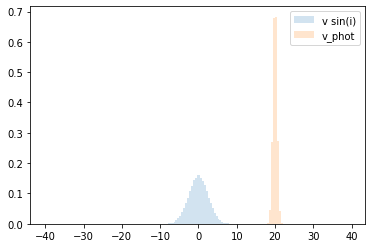

In [3]:
plt.hist(vsini, alpha=0.2,density=True,bins=bins, label='v sin(i)')
plt.hist(vphot,alpha=0.2,density=True,bins=bins, label='v_phot')
plt.legend()
plt.show()

In [4]:
vsini_over_vphot=vsini/vphot

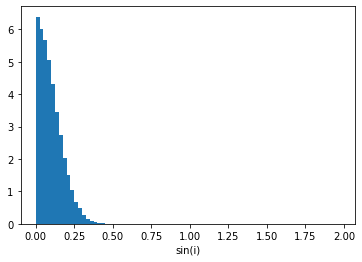

In [5]:
plt.hist(vsini_over_vphot,density=True,bins=np.arange(0,2,0.025))
plt.xlabel('sin(i)')
plt.show()

In [6]:
arcsini=np.arcsin(vsini_over_vphot)

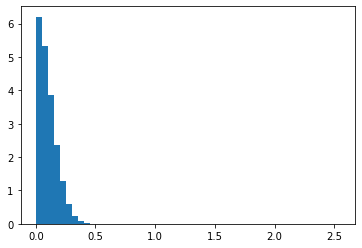

In [7]:
plt.hist(arcsini,bins=np.arange(0,np.pi/2+1,0.05),density=True)
plt.show()

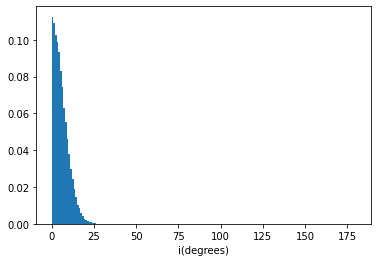

In [8]:
plt.hist(arcsini*180./np.pi,bins=np.arange(0,181,1.),density=True)
plt.xlabel('i(degrees)')
plt.show()

In [9]:
cosi=np.cos(arcsini)

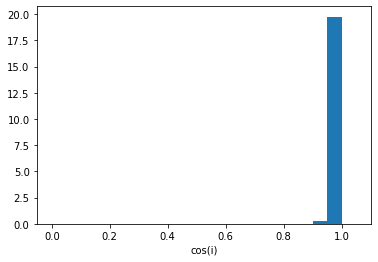

In [10]:
plt.hist(cosi,bins=np.arange(0,1.1,0.05),density=True)
plt.xlabel('cos(i)')
plt.show()

So it does appear that naturally the result of having v sin(i) $\approx$ v is a roughly gaussian cos(i) distribution. This does beg the question though of *why* you would plot cos(i) instead of sin(i)... sin(i) completely displays the inherent uncertainties. All of these transforms introduce nan's that ruin your life

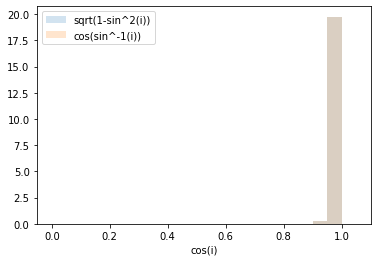

In [11]:
plt.hist(np.sqrt(1-vsini_over_vphot**2),bins=np.arange(0,1.1,0.05),density=True, label='sqrt(1-sin^2(i))',alpha=0.2)
plt.hist(cosi,bins=np.arange(0,1.1,0.05),density=True, label='cos(sin^-1(i))',alpha=0.2)
plt.xlabel('cos(i)')
plt.legend()
plt.show()

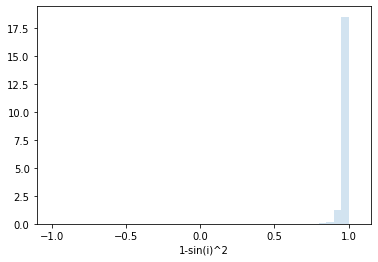

In [12]:
plt.hist(1-vsini_over_vphot**2,bins=np.arange(-1,1.1,0.05),density=True, label='sqrt(1-sin^2(i))',alpha=0.2)
plt.xlabel('1-sin(i)^2')
plt.show()

And it appears that either route to this conclusion runs into the exact same numerical boundaries.

In [13]:
print('fraction of solutions in final answer',cosi.shape[0]/vsini.shape[0])


fraction of solutions in final answer 1.0


In [14]:
print(cosi.shape[0])
vsini.shape[0]

100000


100000

In [15]:
np.min(cosi)

0.8358558461926116

In [16]:
print('Actually the fraction of solutions that are used in the final answer',(cosi.shape[0]-np.sum(np.isnan(cosi)))/vsini.shape[0])

Actually the fraction of solutions that are used in the final answer 1.0


So that's pretty much the fraction we would expect to be inside the boundaries if everything we did was correct.

Again though. Why on Earth would they plot the distribution in cos(i) instead of sin(i)? 

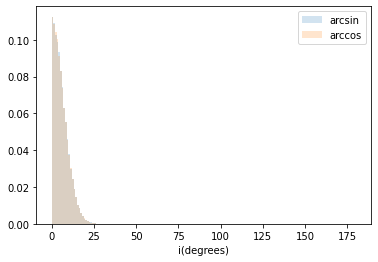

In [17]:
plt.hist(arcsini*180./np.pi,bins=np.arange(0,181,1.),density=True,label='arcsin',alpha=0.2)
plt.hist(np.arccos(cosi)*180./np.pi,bins=np.arange(0,181,1.),density=True, label='arccos',alpha=0.2)
plt.xlabel('i(degrees)')
plt.legend()
plt.show()

In [18]:
print(np.nanmedian(arcsini*180/np.pi),np.nanpercentile(arcsini*180./np.pi,26.),np.nanpercentile(arcsini*180./np.pi,84.))

-0.016945191560338198 -4.595639238349665 7.091469440851209


In [19]:
print(np.__version__)

1.19.3
